# Circuit compilation and connectivity

In this notebook we will cover some basic strategies for compiling valid quantum circuits when qubit connectivity is limited.


### Packages

Before using this notebook, make sure the following packages are installed in your Python environment:

- `qiskit` (versions 2.1.2 and 2.3.0 have been tested and work fine)
- `qiskit-aer` (version 0.17.2)
- `pylatexenc`

If you have trouble installing the packages locally, you can run the notebook on [Google Colab](https://colab.research.google.com). In that case, run the following cell once before proceeding.


In [ ]:
%pip install --quiet "qiskit==2.1.2" "qiskit-aer==0.17.2" pylatexenc

### Accessing real backends

During the School we will provide access to both the Lagrange machine and IBM Quantum hardware. Access to real hardware is **not required** for the preparatory work in this notebook: all examples below can be run using local fake backends.

If you already have access and want to experiment with the real devices, you can use the following optional snippets after installing the corresponding provider packages and configuring your credentials.


In [ ]:
## IBM Quantum
#from qiskit_ibm_runtime import QiskitRuntimeService

## IQM Lagrange
#from iqm.qiskit_iqm import IQMProvider

## Load saved IBM Quantum credentials
#ibmq_service = QiskitRuntimeService()

## Load access to Lagrange
#!lagrangeclient


For Lagrange, the backend can then be loaded as follows (uncomment the cell first and adapt the credential path if needed).


In [ ]:
#import os
### get the backend for Lagrange
#os.environ["IQM_TOKENS_FILE"] = "./tokens.json"
#iqm_url = "https://spark.quantum.linksfoundation.com/"
#quantum_computer = "default"

#lagrange_provider = IQMProvider(iqm_url,quantum_computer=quantum_computer)
#lagrange_backend = lagrange_provider.get_backend()

For IBM Quantum, you can similarly select an available backend. As an example, the following line selects `ibm_fez`.


In [ ]:
#backend_fez = ibmq_service.backend('ibm_fez')

For the remainder of the notebook we will not assume access to real hardware. Instead, we will create local fake backends with the connectivity we want to study. If you do have access to the real devices, you can later repeat the same transpilation experiments by changing the backend.


### Initialize a backend with a specified connectivity

We first generate a local backend with a connectivity similar to that of Lagrange.


In [1]:
from qiskit.providers.fake_provider import GenericBackendV2

# Star-like connectivity used throughout this notebook.
# In this first backend we intentionally keep the edges directed,
# because the default two-qubit basis gate is CX and its direction matters.
lagrange_edges = [(0, 2), (1, 2), (2, 3), (2, 4)]

fake_lagrange_backend = GenericBackendV2(
    num_qubits=5,
    coupling_map=lagrange_edges
)

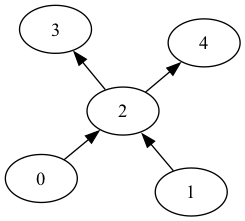

In [2]:
# We can plot the coupling map directly using the draw method.
fake_lagrange_backend.coupling_map.draw()

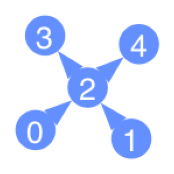

In [3]:
from qiskit.visualization import plot_coupling_map

# Or use the plotting utility available in Qiskit.
plot_coupling_map(
    num_qubits=fake_lagrange_backend.coupling_map.size(),
    qubit_coordinates=None,
    coupling_map=fake_lagrange_backend.coupling_map.get_edges(),
    plot_directed=True,
    figsize=(2, 2)
)

Many superconducting quantum processors use sparse connectivity graphs rather than all-to-all connectivity. IBM Quantum devices, for example, use heavy-hex-derived topologies. You can inspect the coupling map and other backend information on the IBM Quantum platform (for instance for [`ibm_fez`](https://quantum.cloud.ibm.com/computers?system=ibm_fez)).

The following cell generates a small heavy-hex coupling map locally for illustration.


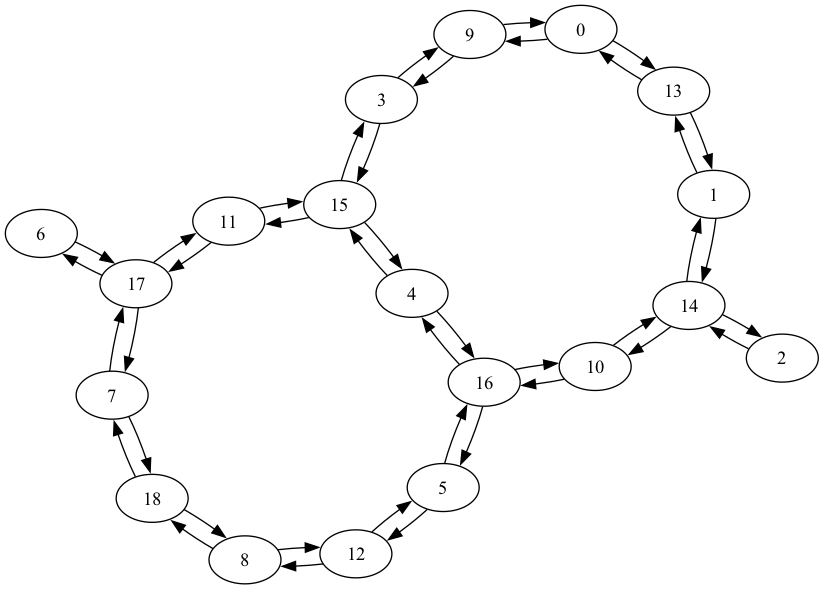

In [4]:
from qiskit.transpiler import CouplingMap
# here we just generate and plot the coupling map.
CouplingMap.from_heavy_hex(3).draw()
## If you want to initialize a backend with this coupling map you can use instead the following code
#
#cm = CouplingMap.from_heavy_hex(3)
## Generate a simulated backend from a given coupling map
#fake_ibmq_backend = GenericBackendV2(
#    num_qubits=cm.size(),
#    coupling_map=cm
#)

### Impact of connectivity

A coupling map tells us which pairs of physical qubits can participate directly in two-qubit gates. It can also encode a **direction** for the allowed interaction.

Direction matters for asymmetric gates such as $CX$ (or CNOT). For example, if a backend allows $CX(0,2)$ but not $CX(2,0)$, the direction can be reversed using

$$
CX(q_0,q_1)
=
H(q_0)H(q_1)\,CX(q_1,q_0)\,H(q_0)H(q_1).
$$

This is the same identity discussed in the `Basic_Gates_and_Pauli_exponentials` notebook.

For a symmetric entangling gate such as $CZ$, exchanging the two qubits does not change the unitary. Therefore, when we use $CZ$ to model the Lagrange connectivity below, we will explicitly represent each physical link in both directions in the coupling map.

To inspect the instructions supported by a backend, we can use:


In [5]:
fake_lagrange_backend.instructions

[(Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), (0, 2)),
 (Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), (1, 2)),
 (Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), (2, 3)),
 (Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), (2, 4)),
 (Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (0,)),
 (Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (1,)),
 (Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (2,)),
 (Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (3,)),
 (Instruction(name='id', num_qubits=1, num_clbits=0, params=[]), (4,)),
 (Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
  (0,)),
 (Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
  (1,)),
 (Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
  (2,)),
 (Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
  (3,)),


The generic backend initialized above uses $CX$ as its default two-qubit basis gate. For a simplified model closer to the situation we want to study for Lagrange, we can instead construct a backend whose entangling basis gate is $CZ$ and whose physical links are represented bidirectionally.


In [6]:
# Represent every physical link in both directions.
lagrange_bidirectional_edges = lagrange_edges + [(b, a) for a, b in lagrange_edges]

better_fake_lagrange_backend = GenericBackendV2(
    num_qubits=5,
    coupling_map=lagrange_bidirectional_edges,
    basis_gates=["id", "rz", "sx", "x", "cz"]
)

### Example 1: Bell-pair preparation

Imagine that we want to generate the Bell state

$$
|\Phi\rangle=\frac{|00\rangle+|11\rangle}{\sqrt{2}}.
$$

At the logical-circuit level, there are at least two equivalent ways to prepare it.


In [7]:
from qiskit import transpile
from qiskit import QuantumCircuit

## this is the first version
circuitA = QuantumCircuit(2)
circuitA.h(0)
circuitA.cx(0, 1)

print(circuitA.draw('text'))

## and this is the second
circuitB = QuantumCircuit(2)
circuitB.h(1)
circuitB.cx(1, 0)
print(circuitB.draw('text'))

     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
          ┌───┐
q_0: ─────┤ X ├
     ┌───┐└─┬─┘
q_1: ┤ H ├──■──
     └───┘     


Let us now compile the circuits for the first, CX-based fake Lagrange backend.

If we do not specify an initial layout and use `optimization_level=0`, Qiskit starts from a very simple placement and may need an additional physical qubit for routing when the two initially chosen qubits are not directly connected. The exact transpiled circuit can depend on the Qiskit version and on heuristic choices made by the transpiler.


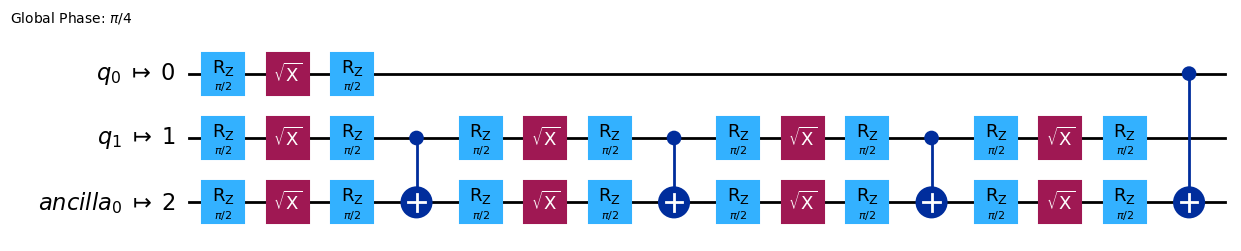

In [8]:
from qiskit import transpile

transpiled_circuitA = transpile(circuitA, backend=fake_lagrange_backend,optimization_level=0)
transpiled_circuitA.draw('mpl')

At higher optimization levels, the transpiler is allowed to spend more effort on layout selection and circuit optimization. For this simple example it can usually find a better placement automatically.


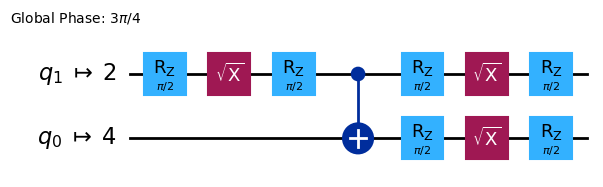

In [9]:
transpiled_circuitA = transpile(circuitA, backend=fake_lagrange_backend,optimization_level=1)
transpiled_circuitA.draw('mpl')

Since we have not fixed the physical qubits, compiling `circuitB` in the same way can lead to the same or an equivalent physical implementation.


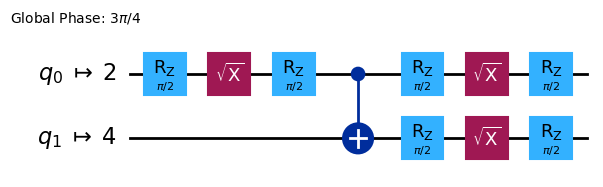

In [10]:
transpiled_circuitB = transpile(circuitB, backend=fake_lagrange_backend,optimization_level=1)
transpiled_circuitB.draw('mpl')

Often, however, we want to specify which physical qubits should initially represent the logical qubits. We can do this with the `initial_layout` option of `transpile`.


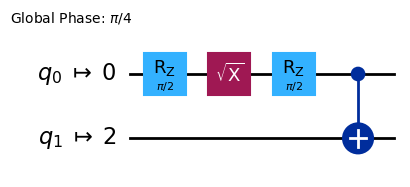

In [11]:
transpiled_circuitA = transpile(
    circuitA,
    backend=fake_lagrange_backend,
    optimization_level=0,
    initial_layout=[0,2]
)
transpiled_circuitA.draw('mpl')

Note how, even with `optimization_level=0`, choosing a suitable initial layout can avoid unnecessary routing.

If we now compile `circuitB` with the same initial layout, logical qubits `q_0` and `q_1` are still mapped initially to physical qubits $0$ and $2$, but the direction of the logical CNOT is reversed. For the directed CX backend this requires additional single-qubit gates.


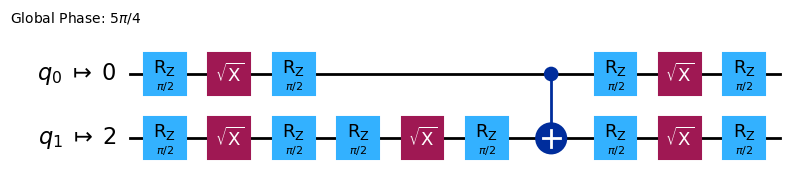

In [12]:
transpiled_circuitB = transpile(
    circuitB,
    backend=fake_lagrange_backend,
    optimization_level=0,
    initial_layout=[0,2]
)
transpiled_circuitB.draw('mpl')

If the entangling basis gate is instead the symmetric $CZ$, the direction of the two-qubit interaction is no longer an issue.


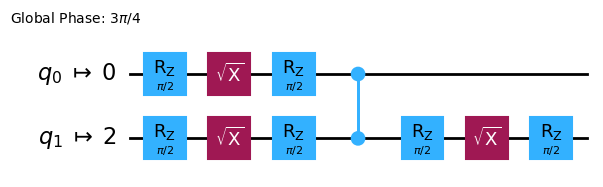

In [13]:
transpiled_circuitA = transpile(
    circuitA,
    backend=better_fake_lagrange_backend,
    optimization_level=0,
    initial_layout=[0,2]
)
transpiled_circuitA.draw('mpl')

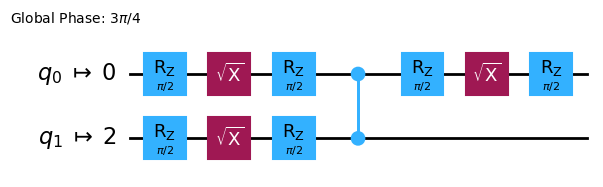

In [14]:
transpiled_circuitB = transpile(
    circuitB,
    backend=better_fake_lagrange_backend,
    optimization_level=0,
    initial_layout=[0,2]
)
transpiled_circuitB.draw('mpl')

For the examples in this notebook, `optimization_level=2` is a reasonable default and is also Qiskit's default optimization level.

Keep in mind, however, that specifying `initial_layout` fixes only the **initial** logical-to-physical assignment. During routing, the transpiler may still insert SWAP operations and change the final logical-to-physical permutation. Higher optimization levels also do more than simply minimize the total number of gates.


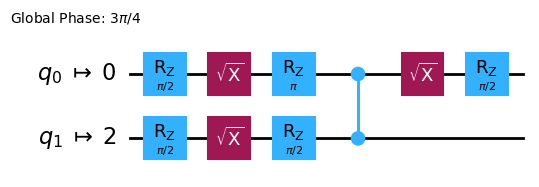

In [15]:
transpiled_circuitB_opt = transpile(
    circuitB,
    backend=better_fake_lagrange_backend,
    optimization_level=2,
    initial_layout=[0,2]
)
transpiled_circuitB_opt.draw('mpl')

### Example 2: GHZ preparation

Preparing a Bell pair is relatively easy because we only need one suitable connection. To make the connectivity problem more interesting, let us consider multi-qubit GHZ states:

$$
|GHZ_3\rangle=\frac{|000\rangle+|111\rangle}{\sqrt{2}},
$$

$$
|GHZ_4\rangle=\frac{|0000\rangle+|1111\rangle}{\sqrt{2}},
$$

$$
|GHZ_5\rangle=\frac{|00000\rangle+|11111\rangle}{\sqrt{2}}.
$$

The definition generalizes to any number of qubits, but we stop at five because our Lagrange-like backend has five qubits.


For instance, an idealized circuit that prepares $|GHZ_3\rangle$ is:


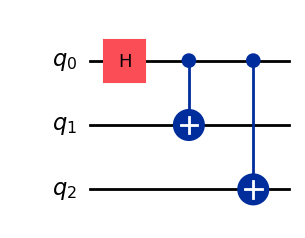

In [16]:
circuitA = QuantumCircuit(3)
circuitA.h(0)
circuitA.cx(0, 1)
circuitA.cx(0, 2)
circuitA.draw('mpl')

A simple way to make this circuit compatible with the star-like connectivity is to map logical qubit `q_0`, which acts as the control, to physical qubit $2$.


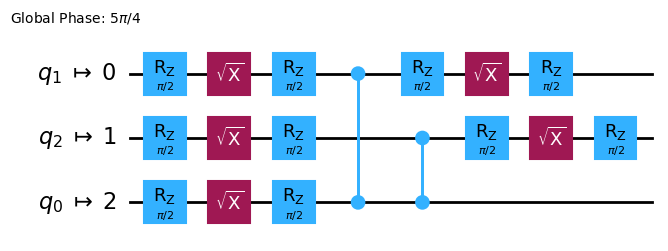

In [17]:
transpiled_circuitA = transpile(
    circuitA,
    backend=better_fake_lagrange_backend,
    optimization_level=0,
    initial_layout=[2,0,1]
)
transpiled_circuitA.draw('mpl')

Convince yourself that the same strategy allows us to prepare all three GHZ states defined above without additional routing overhead: the logical control qubit can be placed on the central physical qubit.

The structure is simple enough that `optimization_level=2` may also discover a suitable layout automatically. Try it.


### Example 3: GHZ-state preparation with a fixed layout

So far we have exploited the freedom to choose the physical qubits. Sometimes, however, the initial layout is dictated by other considerations, such as additional gates that must be performed later in the circuit.

In that case we may need to move quantum information during the computation. The standard tool is the $SWAP$ gate,

$$
SWAP =
\begin{pmatrix}
1&0&0&0\\
0&0&1&0\\
0&1&0&0\\
0&0&0&1
\end{pmatrix}.
$$


A SWAP can be decomposed straightforwardly into three CNOT gates:


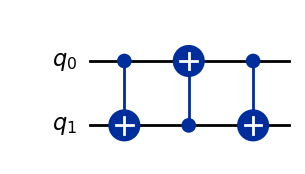

In [18]:
swap_circuitA=QuantumCircuit(2)
swap_circuitA.cx(0,1)
swap_circuitA.cx(1,0)
swap_circuitA.cx(0,1)
swap_circuitA.draw('mpl')

The following reversed ordering of the three CNOTs is equivalent. Why?


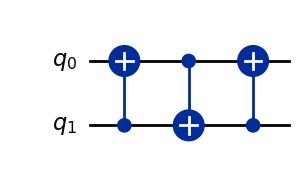

In [19]:
swap_circuitB=QuantumCircuit(2)
swap_circuitB.cx(1,0)
swap_circuitB.cx(0,1)
swap_circuitB.cx(1,0)
swap_circuitB.draw('mpl')

Using SWAP gates, we can always construct a circuit that respects a connected coupling graph.

For example, consider the $|GHZ_3\rangle$ circuit with the fixed initial layout $[0,1,2]$. Physical qubits $0$ and $1$ are not directly connected in our star-like topology. One possible strategy is therefore to swap the states of physical qubits $0$ and $2$, perform the required interaction using the central qubit, and then swap back to restore the original ordering.


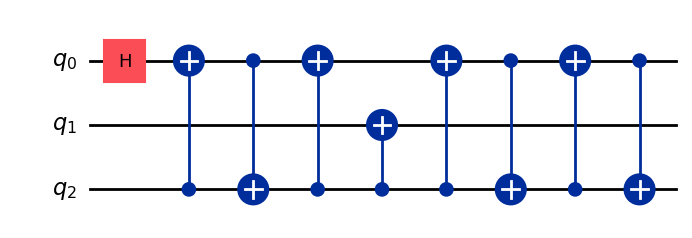

In [20]:
circuitA_full_SWAP = QuantumCircuit(3)
circuitA_full_SWAP.h(0)
## this is the operation we can't do
#circuitA_full_SWAP.cx(0, 1)
## swap 0 <-> 2
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
## cx(0, 1) now is cx(2, 1)
circuitA_full_SWAP.cx(2, 1)
## swap 0 <-> 2
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.draw('mpl')

Blindly inserting full SWAPs makes the circuit executable, but it is usually not optimal.

A first simple optimization comes from noticing that a SWAP has two equivalent three-CNOT decompositions with opposite orderings. Choosing the decomposition carefully can expose adjacent identical CNOT gates that cancel.


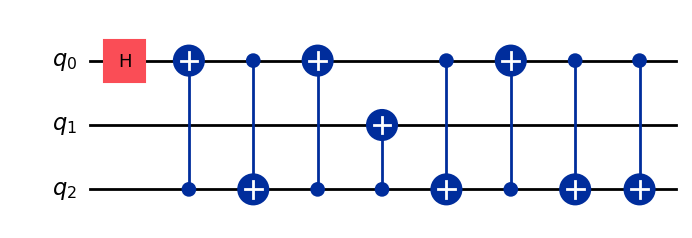

In [21]:
circuitA_full_SWAP = QuantumCircuit(3)
circuitA_full_SWAP.h(0)
## this is the operation we can't do
#circuitA_full_SWAP.cx(0, 1)
## swap 0 <-> 2
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
## cx(0, 1) now is cx(2, 1)
circuitA_full_SWAP.cx(2, 1)
## swap 0 <-> 2
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.draw('mpl')

After cancelling the adjacent identical CNOT gates, the circuit is equivalent to:


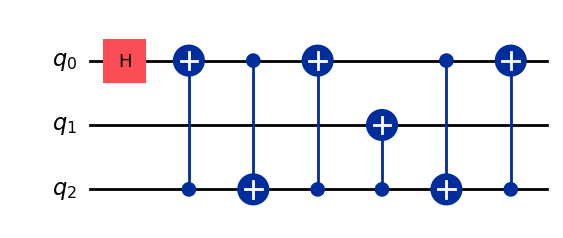

In [22]:
circuitA_full_SWAP = QuantumCircuit(3)
circuitA_full_SWAP.h(0)
## this is the operation we can't do
#circuitA_full_SWAP.cx(0, 1)
## swap 0 <-> 2
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
## cx(0, 1) now is cx(2, 1)
circuitA_full_SWAP.cx(2, 1)
## swap 0 <-> 2
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.draw('mpl')

Because this is a **state-preparation** circuit and all qubits initially start in $|0\rangle$, we can simplify it one step further. The first $CX(2,0)$ in the leftmost SWAP decomposition acts trivially on the initial state, so it can be omitted for this particular state-preparation task.


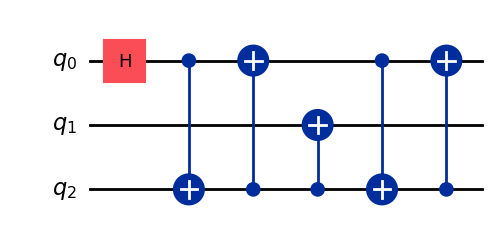

In [23]:
circuitA_full_SWAP = QuantumCircuit(3)
circuitA_full_SWAP.h(0)
## this is the operation we can't do
#circuitA_full_SWAP.cx(0, 1)
## swap 0 <-> 2
#circuitA_full_SWAP.cx(2, 0)# not needed if this is at the beginning
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
## cx(0, 1) now is cx(2, 1)
circuitA_full_SWAP.cx(2, 1)
## swap 0 <-> 2
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.draw('mpl')

**Note:** this last simplification uses knowledge of the input state. It is valid for this state-preparation problem, but it is not a general unitary identity. Do not make the same simplification in a circuit that must act correctly on an arbitrary input state.


If we transpile this state-preparation circuit to the CZ-based fake backend, the implementation uses five $CZ$ gates in the tested setup.


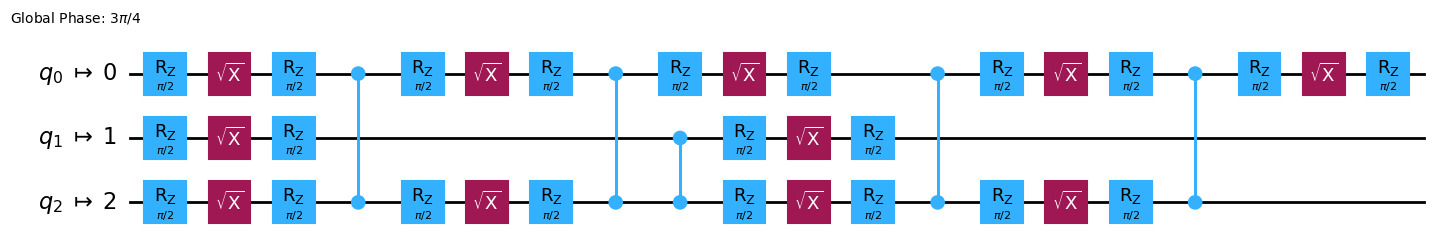

In [24]:
transpiledA_full_SWAP = transpile(
    circuitA_full_SWAP,
    backend=better_fake_lagrange_backend,
    optimization_level=0,
    initial_layout=[0,1,2]
)
transpiledA_full_SWAP.draw('mpl')

Further optimization mainly reduces single-qubit $R_Z$ operations in this example. On many superconducting platforms, $R_Z$ rotations are implemented virtually and are therefore much cheaper than entangling gates, but it is better not to describe them as literally free in a hardware-independent discussion.


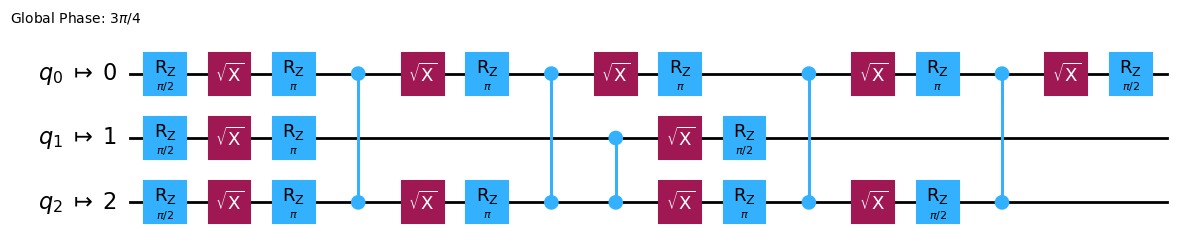

In [25]:
transpiledA_full_SWAP = transpile(
    circuitA_full_SWAP,
    backend=better_fake_lagrange_backend,
    optimization_level=2,
    initial_layout=[0,1,2]
)
transpiledA_full_SWAP.draw('mpl')

The transpiler's job is to produce a circuit compatible with the target backend. Let us now see what it does when we give it the original logical circuit and the fixed initial layout instead of inserting SWAPs by hand.


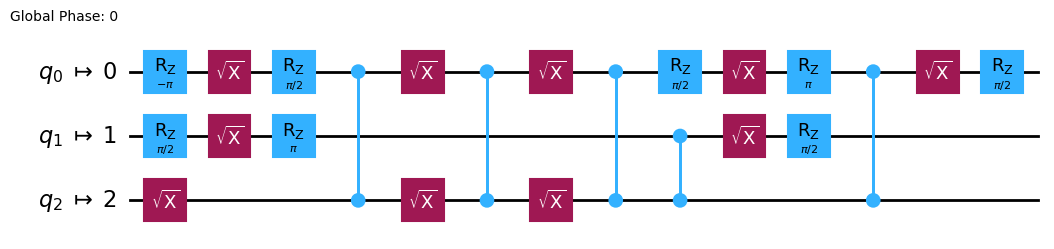

In [26]:
transpiledA_auto_transpile = transpile(
    circuitA,
    backend=better_fake_lagrange_backend,
    optimization_level=2,
    initial_layout=[0,1,2]
)
transpiledA_auto_transpile.draw('mpl')

In the tested setup, the transpiled circuit again uses five $CZ$ gates, but its structure is different. A useful way to understand the result is to compare it with the following circuit.


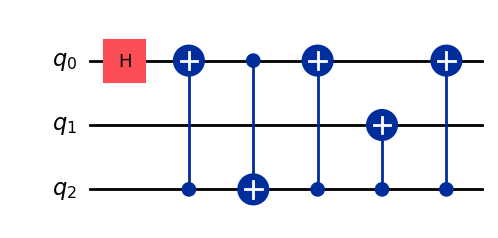

In [27]:
circuitA_full_SWAP = QuantumCircuit(3)
circuitA_full_SWAP.h(0)
## this is the operation we can't do
#circuitA_full_SWAP.cx(0, 1)
## swap 0 <-> 2
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.cx(0, 2)
circuitA_full_SWAP.cx(2, 0)
## cx(0, 1) now is cx(2, 1)
circuitA_full_SWAP.cx(2, 1)
## now we don't swap back but simply use
## cx(0, 2) now is cx(2, 0)
circuitA_full_SWAP.cx(2, 0)
circuitA_full_SWAP.draw('mpl')

The important point is that the transpiler does not necessarily restore the original logical-to-physical ordering after routing. After moving quantum information through the device, it can keep a different final permutation and account for that permutation when compiling subsequent logical gates.

Qiskit records this information in the transpilation layout. In particular, the transpiled circuit has a `layout` object, and `layout.final_index_layout()` can be used to inspect where the states of the original logical qubits end up.

To make this visible, let us add an $X$ gate to logical qubit `q_2` **before** transpilation and see where the operation is placed in the physical circuit.


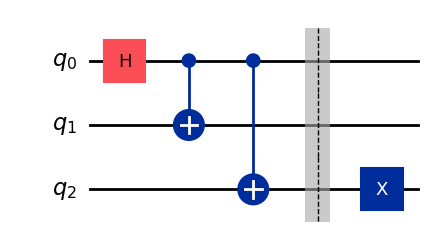

In [28]:
circuitA_plusX2 = QuantumCircuit(3)
circuitA_plusX2.h(0)
circuitA_plusX2.cx(0, 1)
circuitA_plusX2.cx(0, 2)
# here we are adding a barrier to avoid moving the next gate back
circuitA_plusX2.barrier()
circuitA_plusX2.x(2)
circuitA_plusX2.draw('mpl')

In [29]:
transpiledA_auto_transpile = transpile(
    circuitA_plusX2,
    backend=better_fake_lagrange_backend,
    optimization_level=2,
    initial_layout=[0, 1, 2]
)
transpiledA_auto_transpile.draw('mpl')

print("Final logical-to-physical layout:",
      transpiledA_auto_transpile.layout.final_index_layout())

Final logical-to-physical layout: [2, 1, 0]


The $X$ gate is placed on the physical qubit that contains the state of logical qubit `q_2` at that point in the compiled circuit.

**Important:** a transpiled circuit is expressed in terms of the physical qubits and its current layout. Appending a gate to physical index `2` after transpilation is therefore **not** automatically the same as appending a gate to logical qubit `q_2`.

The safest workflow is to modify the original logical circuit and transpile it again. If you intentionally modify a transpiled circuit, you must explicitly account for its layout.


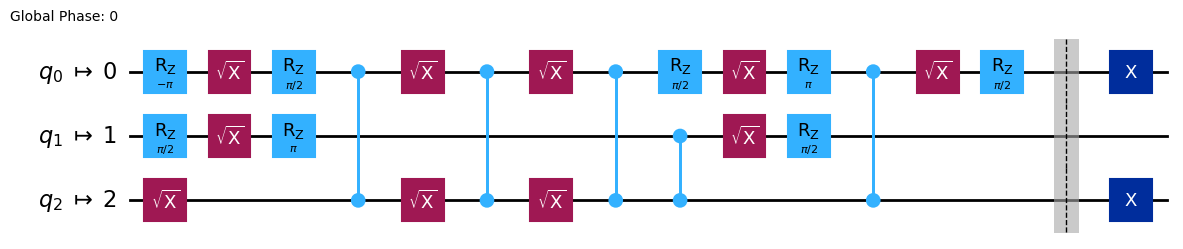

In [30]:
transpiledA_auto_transpile.x(2)
transpiledA_auto_transpile.draw('mpl')

# Exercise 1

Imagine we want to use the following three circuits for preparing the $GHZ$ states

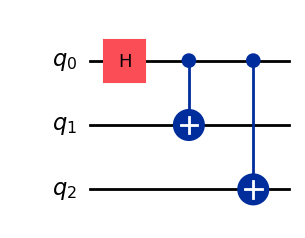

In [31]:
circuit_ghz3 = QuantumCircuit(3)
circuit_ghz3.h(0)
circuit_ghz3.cx(0, 1)
circuit_ghz3.cx(0, 2)
circuit_ghz3.draw('mpl')

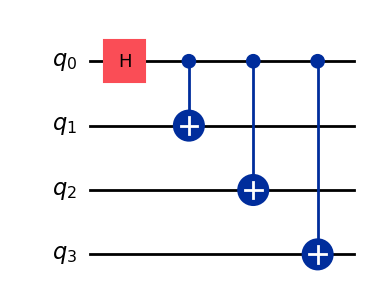

In [32]:
circuit_ghz4 = QuantumCircuit(4)
circuit_ghz4.h(0)
circuit_ghz4.cx(0, 1)
circuit_ghz4.cx(0, 2)
circuit_ghz4.cx(0, 3)
circuit_ghz4.draw('mpl')

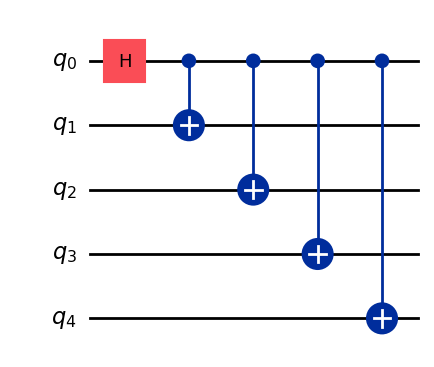

In [33]:
circuit_ghz5 = QuantumCircuit(5)
circuit_ghz5.h(0)
circuit_ghz5.cx(0, 1)
circuit_ghz5.cx(0, 2)
circuit_ghz5.cx(0, 3)
circuit_ghz5.cx(0, 4)
circuit_ghz5.draw('mpl')

We will use, respectively, the fixed initial layouts $[0,1,2]$, $[0,1,2,3]$, and $[0,1,2,3,4]$ on the Lagrange-like connectivity.

Use the transpiler output as your baseline and count the number of $CZ$ gates it produces. In the environment used to prepare this notebook, the corresponding counts were $5$, $6$, and $7$, but the exact routed circuit can vary because some transpiler passes are heuristic and stochastic.

- Can you beat the transpiler **without** using the fact that the initial state is $|0\ldots0\rangle$?
- How much further can you reduce the circuit if you are allowed to exploit the known initial state?

For useful identities involving circuits with many CNOT gates, you may want to look at [this paper](https://arxiv.org/abs/1110.2998).

Once you have done that, repeat the same optimization exercise for GHZ preparation on a one-dimensional line with nearest-neighbor connectivity only. The following cell creates a suitable fake backend.


In [34]:
# Generate a simulated backend from a given coupling map
fake_line_backend = GenericBackendV2(
    num_qubits=5,
    coupling_map=CouplingMap.from_line(5)
)

# Exercise 2

Imagine that we want to implement the following unitary transformation:

$$
U(\theta) =
\exp\left(-i\theta Z_0Z_1Z_2\right)
\exp\left(-i\theta Z_0Z_1\right)
\exp\left(-i\theta Z_0Z_1Z_3\right)
\exp\left(-i\theta Z_0Z_1Z_2Z_3\right).
$$

With all-to-all connectivity, a naive compilation following the Pauli-exponentiation strategy introduced in the previous notebook would use $16$ CNOT gates and $4$ $R_Z$ gates.

By exploiting cancellations between neighboring parts of the circuit, this can already be reduced substantially. In the environment used to prepare this notebook, the transpiler finds an implementation with $8$ CNOT gates when connectivity is not restricted.

- Can you beat this transpiler result without worrying about qubit connectivity? What is your best CNOT count?

**Hint:** the four Pauli exponentials above all commute with one another. You are therefore free to choose their order.

If we now impose the Lagrange-like connectivity and use the initial layout $[0,2,1,3]$, the tested transpiler setup produces a circuit with $14$ CNOT gates.

- How many **connectivity-valid** CNOT gates do you need to implement $U(\theta)$?

**Hint:** for circuits of this type, it is often convenient to use the qubit connected to all the others as the target of the parity-computation network.

<details>
  <summary>Additional hint — open only after you have tried your own optimization</summary>

  Because the Pauli terms commute, try reordering them so that parity information already computed for one exponential can be reused by the next one instead of being completely uncomputed each time.
</details>


### BONUS

If all of this seemed **way too easy** and you would still like more practice optimizing circuits under connectivity constraints, have a look at the hand-crafted circuit implementations in:

- Appendix F of [this paper](https://arxiv.org/abs/2009.13485)
- Appendix B of [this paper](https://arxiv.org/abs/2111.02982)
- Appendix C of [this paper](https://arxiv.org/pdf/2503.00607)

These are examples of circuit layouts optimized by hand to reduce the impact of limited connectivity. Start from the corresponding original circuits and compare your optimized implementation with the published one.

If yours is better, please let us know!
